# FedProx EQUAL WEIGHTING

### Colab config

In [1]:
# First cell in Colab
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"GPU name      : {torch.cuda.get_device_name(0)}")
# Should print: Tesla T4 or similar

# Install dependencies
!pip install torchvision torch -q

Mounted at /content/drive
GPU available : True
GPU name      : Tesla T4


### Setting Working Directory

In [2]:
import os

curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")
os.chdir('/content/drive/MyDrive/BREAST_CANCER_FL/')
print("Changing to root directory...")

print(f"Working in: '{os.getcwd()}'")

Current directory: '/content'
Changing to root directory...
Working in: '/content/drive/MyDrive/BREAST_CANCER_FL'


###  Imports and Setup

In [3]:
import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from PIL import Image
from torch.utils.data import (
    DataLoader, Dataset,
    TensorDataset, WeightedRandomSampler
)
from torchvision import transforms
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/BREAST_CANCER_FL/'

import sys
sys.path.append(BASE_PATH)

from model_architectures import (
    EMBEDDING_DIM,
    SharedClassificationHead,
    Hospital1_Encoder, Hospital1_MLP,
    Hospital2_Encoder, Hospital2_MLP,
    Hospital3_Encoder, Hospital3_CNN
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(
    os.path.join(BASE_PATH, 'models/federated/fedprox'),
    exist_ok=True
)
os.makedirs(
    os.path.join(BASE_PATH, 'results/federated/fedprox'),
    exist_ok=True
)

print("="*70)
print("  STEP 2 — FedProx EQUAL WEIGHTING")
print("="*70)
print(f"\n  Device          : {device}")
print(f"  EMBEDDING_DIM   : {EMBEDDING_DIM}")
print(f"\n  What FedProx adds over FedAvg Equal:")
print(f"  During local training each hospital's shared head")
print(f"  is penalized for drifting too far from the global")
print(f"  shared head — controlled by mu hyperparameter")
print(f"\n  mu = 0.01 (proximal strength)")
print(f"  Weighting = Equal (33.3% each)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  STEP 2 — FedProx EQUAL WEIGHTING

  Device          : cuda
  EMBEDDING_DIM   : 64

  What FedProx adds over FedAvg Equal:
  During local training each hospital's shared head
  is penalized for drifting too far from the global
  shared head — controlled by mu hyperparameter

  mu = 0.01 (proximal strength)
  Weighting = Equal (33.3% each)


### Utility Functions

In [4]:
# UTILITY FUNCTIONS
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

def get_shared_head_weights(model):
    return {
        k: v.clone()
        for k, v in model.shared_head.state_dict().items()
    }

def set_shared_head_weights(model, weights):
    model.shared_head.load_state_dict(weights)

def federated_averaging(weights_list, dataset_sizes):
    total_size  = sum(dataset_sizes)
    avg_weights = {}
    for key in weights_list[0].keys():
        avg_weights[key] = sum(
            weights_list[i][key].float() *
            (dataset_sizes[i] / total_size)
            for i in range(len(weights_list))
        )
    return avg_weights

def evaluate_federated_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds    = []
    all_probs    = []
    all_labels   = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(device).float()
            labels  = labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            preds = (outputs > 0.0).float()
            probs = torch.sigmoid(outputs)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels).flatten()
    all_preds  = np.array(all_preds).flatten()
    all_probs  = np.array(all_probs).flatten()

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0

    return {
        'loss'     : running_loss / len(dataloader.dataset),
        'accuracy' : accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall'   : recall_score(all_labels, all_preds, zero_division=0),
        'f1'       : f1_score(all_labels, all_preds, zero_division=0),
        'auc_roc'  : auc
    }

def print_round_summary(round_num, results, algorithm='FedProx'):
    print(f"\n  Round {round_num:02d} [{algorithm}] Results:")
    print(f"  {'Hospital':<25} {'Acc':>6} {'F1':>6} "
          f"{'Recall':>8} {'AUC':>6}")
    print(f"  {'─'*55}")
    for name, metrics in results.items():
        print(f"  {name:<25} "
              f"{metrics['accuracy']:>6.4f} "
              f"{metrics['f1']:>6.4f} "
              f"{metrics['recall']:>8.4f} "
              f"{metrics['auc_roc']:>6.4f}")

print(" Utility functions defined")

 Utility functions defined


### Loading All Datasets

In [5]:
print("="*70)
print("  LOADING ALL HOSPITAL DATASETS")
print("="*70)

# Hospital 1 — WDBC
print("\n Loading Hospital 1 (WDBC)...")

X_train_h1 = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/wdbc/X_train.csv')
).values
y_train_h1 = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/wdbc/y_train.csv')
).values.flatten()
X_test_h1  = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/wdbc/X_test.csv')
).values
y_test_h1  = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/wdbc/y_test.csv')
).values.flatten()

assert X_train_h1.shape[1] == 23, "H1 feature count mismatch"
assert X_train_h1.shape[0] == y_train_h1.shape[0], "H1 size mismatch"

train_dataset_h1 = TensorDataset(
    torch.FloatTensor(X_train_h1),
    torch.FloatTensor(y_train_h1)
)
test_dataset_h1 = TensorDataset(
    torch.FloatTensor(X_test_h1),
    torch.FloatTensor(y_test_h1)
)
generator_h1 = torch.Generator()
generator_h1.manual_seed(42)
train_loader_h1 = DataLoader(
    train_dataset_h1, batch_size=32,
    shuffle=True, generator=generator_h1
)
test_loader_h1 = DataLoader(
    test_dataset_h1, batch_size=32, shuffle=False
)
print(f"  Train: {len(train_dataset_h1)} | "
      f"Test: {len(test_dataset_h1)} | "
      f"Features: {X_train_h1.shape[1]}")

# Hospital 2 — Coimbra
print("\n Loading Hospital 2 (Coimbra)...")

X_train_h2 = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/coimbra/X_train.csv')
).values
y_train_h2 = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/coimbra/y_train.csv')
).values.flatten()
X_test_h2  = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/coimbra/X_test.csv')
).values
y_test_h2  = pd.read_csv(
    os.path.join(BASE_PATH, 'data/processed/coimbra/y_test.csv')
).values.flatten()

assert X_train_h2.shape[1] == 9, "H2 feature count mismatch"
assert X_train_h2.shape[0] == y_train_h2.shape[0], "H2 size mismatch"

train_dataset_h2 = TensorDataset(
    torch.FloatTensor(X_train_h2),
    torch.FloatTensor(y_train_h2)
)
test_dataset_h2 = TensorDataset(
    torch.FloatTensor(X_test_h2),
    torch.FloatTensor(y_test_h2)
)
generator_h2 = torch.Generator()
generator_h2.manual_seed(42)
train_loader_h2 = DataLoader(
    train_dataset_h2, batch_size=16,
    shuffle=True, generator=generator_h2
)
test_loader_h2 = DataLoader(
    test_dataset_h2, batch_size=16, shuffle=False
)
print(f"    Train: {len(train_dataset_h2)} | "
      f"Test: {len(test_dataset_h2)} | "
      f"Features: {X_train_h2.shape[1]}")

# Hospital 3 — BreakHis
print("\n Loading Hospital 3 (BreakHis)...")

class BreakHisDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.images    = []
        self.labels    = []
        valid_ext      = ('.png', '.jpg', '.jpeg')
        for cls, label in [('benign', 0), ('malignant', 1)]:
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(valid_ext):
                        self.images.append(
                            os.path.join(cls_dir, img_name)
                        )
                        self.labels.append(label)
        assert len(self.images) > 0, f"No images in {root_dir}"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

train_transform_h3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
test_transform_h3 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset_h3 = BreakHisDataset(
    os.path.join(BASE_PATH, 'data/processed/breakhis/train'),
    transform=train_transform_h3
)
test_dataset_h3 = BreakHisDataset(
    os.path.join(BASE_PATH, 'data/processed/breakhis/test'),
    transform=test_transform_h3
)

class_weights_h3  = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_dataset_h3.labels
)
sample_weights_h3 = [
    class_weights_h3[l] for l in train_dataset_h3.labels
]
sampler_h3 = WeightedRandomSampler(
    weights=sample_weights_h3,
    num_samples=len(sample_weights_h3),
    replacement=True
)
train_loader_h3 = DataLoader(
    train_dataset_h3, batch_size=32,
    sampler=sampler_h3, num_workers=2, pin_memory=True
)
test_loader_h3 = DataLoader(
    test_dataset_h3, batch_size=32,
    shuffle=False, num_workers=2, pin_memory=True
)
print(f"    Train: {len(train_dataset_h3):,} | "
      f"Test: {len(test_dataset_h3):,}")

dataset_sizes = [
    len(train_dataset_h1),
    len(train_dataset_h2),
    len(train_dataset_h3)
]
equal_sizes = [1, 1, 1]

print(f"\n{'='*45}")
print(f"  ALL DATASETS LOADED")
print(f"{'='*45}")
print(f"  H1: {dataset_sizes[0]} | H2: {dataset_sizes[1]} "
      f"| H3: {dataset_sizes[2]}")
print(f"  Equal weights: {equal_sizes}")
print(f"{'='*45}")

  LOADING ALL HOSPITAL DATASETS

 Loading Hospital 1 (WDBC)...
  Train: 570 | Test: 114 | Features: 23

 Loading Hospital 2 (Coimbra)...
    Train: 92 | Test: 24 | Features: 9

 Loading Hospital 3 (BreakHis)...
    Train: 1,990 | Test: 743

  ALL DATASETS LOADED
  H1: 570 | H2: 92 | H3: 1990
  Equal weights: [1, 1, 1]


### Initialize Models and Optimizers

In [6]:
# INITIALIZING MODELS FROM PHASE 3 WEIGHTS
# Same starting point as Step 1 for fair comparison
print("\n Loading Phase 3 trained weights...")

model_h1_prox = Hospital1_MLP(
    input_size=23, dropout_rate=0.3
).to(device)
model_h1_prox.load_state_dict(
    torch.load(
        os.path.join(BASE_PATH, 'models/trained/hospital1_local.pth'),
        map_location=device
    )
)

model_h2_prox = Hospital2_MLP(
    input_size=9, dropout_rate=0.3
).to(device)
model_h2_prox.load_state_dict(
    torch.load(
        os.path.join(BASE_PATH, 'models/trained/hospital2_local.pth'),
        map_location=device
    )
)

model_h3_prox = Hospital3_CNN(dropout_rate=0.2).to(device)
model_h3_prox.load_state_dict(
    torch.load(
        os.path.join(BASE_PATH, 'models/trained/hospital3_local.pth'),
        map_location=device
    )
)

print("    All models loaded from Phase 3")

# OPTIMIZERS — same as Step 1
optimizer_h1_prox_encoder = optim.Adam(
    model_h1_prox.encoder.parameters(), lr=0.001
)
optimizer_h1_prox_head = optim.Adam(
    model_h1_prox.shared_head.parameters(), lr=0.0005
)
optimizer_h2_prox_encoder = optim.Adam(
    model_h2_prox.encoder.parameters(), lr=0.001
)
optimizer_h2_prox_head = optim.Adam(
    model_h2_prox.shared_head.parameters(), lr=0.0005
)
optimizer_h3_prox_projection = optim.Adam(
    model_h3_prox.encoder.projection.parameters(), lr=0.0001
)
optimizer_h3_prox_head = optim.Adam(
    model_h3_prox.shared_head.parameters(), lr=0.00005
)

# SCHEDULERS
scheduler_h1_prox_encoder = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h1_prox_encoder, mode='min', patience=5, factor=0.5
)
scheduler_h1_prox_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h1_prox_head, mode='min', patience=5, factor=0.5
)
scheduler_h2_prox_encoder = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h2_prox_encoder, mode='min', patience=3, factor=0.5
)
scheduler_h2_prox_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h2_prox_head, mode='min', patience=3, factor=0.5
)
scheduler_h3_prox_projection = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h3_prox_projection, mode='min', patience=5, factor=0.5
)
scheduler_h3_prox_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h3_prox_head, mode='min', patience=5, factor=0.5
)

criterion = nn.BCEWithLogitsLoss()

print(" Optimizers and schedulers defined")
print(f"   H1 encoder LR   : 0.001")
print(f"   H1 head LR      : 0.0005")
print(f"   H2 encoder LR   : 0.001")
print(f"   H2 head LR      : 0.0005")
print(f"   H3 proj LR      : 0.0001")
print(f"   H3 head LR      : 0.00005")


 Loading Phase 3 trained weights...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 138MB/s]


    All models loaded from Phase 3
 Optimizers and schedulers defined
   H1 encoder LR   : 0.001
   H1 head LR      : 0.0005
   H2 encoder LR   : 0.001
   H2 head LR      : 0.0005
   H3 proj LR      : 0.0001
   H3 head LR      : 0.00005


### FedProx Training Loop

In [8]:
# ============================================================
# FedProx TRAINING LOOP
# Key difference from FedAvg:
#   During local training the shared head loss includes
#   a proximal term that penalizes deviation from the
#   current global shared head weights
#
# Loss = classification_loss + (mu/2) * ||local - global||²
#
# This prevents client drift — the main failure mode
# observed in Step 1 (Hospital 1 Round 1 crash)
# ============================================================
num_fl_rounds_prox = 25
local_epochs_prox  = 2
best_fl_loss_prox  = float('inf')
mu                 = 0.01   # proximal strength hyperparameter

fl_history_prox = {
    'round'        : [],
    'h1_train_loss': [], 'h1_train_acc': [],
    'h2_train_loss': [], 'h2_train_acc': [],
    'h3_train_loss': [], 'h3_train_acc': [],
    'h1_test_acc'  : [], 'h1_test_f1'  : [], 'h1_test_auc': [],
    'h2_test_acc'  : [], 'h2_test_f1'  : [], 'h2_test_auc': [],
    'h3_test_acc'  : [], 'h3_test_f1'  : [], 'h3_test_auc': [],
    'avg_test_acc' : [], 'avg_test_f1' : [], 'avg_test_auc': []
}

# Initialize global shared head reference
# Used by proximal term during local training
global_head_ref = copy.deepcopy(
    model_h1_prox.shared_head.state_dict()
)

print("\n" + "="*70)
print("  FL TRAINING — FedProx EQUAL WEIGHTING")
print("="*70)
print(f"\n  Rounds        : {num_fl_rounds_prox}")
print(f"  Local epochs  : {local_epochs_prox}")
print(f"  mu (proximal) : {mu}")
print(f"  Weighting     : Equal (33.3% each)")
print(f"\n  Starting...\n")

for fl_round in range(num_fl_rounds_prox):

    print(f"\n{'='*55}")
    print(f"  FL ROUND {fl_round+1:02d}/{num_fl_rounds_prox} — FedProx")
    print(f"{'='*55}")

    # STEP 1 — FedProx Local Training
    # Each hospital trains with proximal term
    print(f"\n   Local Training ({local_epochs_prox} epochs each)...")

    def fedprox_local_train(
        model, dataloader, criterion,
        optimizer_encoder, optimizer_head,
        global_head_ref, mu, device
    ):
        """
        FedProx local training for one epoch.
        Adds proximal term to shared head loss only.
        Encoder trains freely without proximal constraint.
        """
        model.train()
        running_loss = 0.0
        all_preds    = []
        all_labels   = []

        for inputs, labels in dataloader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).float().view(-1, 1)

            optimizer_encoder.zero_grad(set_to_none=True)
            optimizer_head.zero_grad(set_to_none=True)

            outputs = model(inputs)

            # Classification loss
            cls_loss = criterion(outputs, labels)

            # Proximal term — shared head only
            # Penalizes deviation from global shared head
            prox_term = sum(
                (local_p - global_p.to(device)).norm() ** 2
                for local_p, global_p in zip(
                    model.shared_head.parameters(),
                    [
                        v for v in global_head_ref.values()
                        if v.requires_grad or True
                    ]
                )
            )

            total_loss = cls_loss + (mu / 2) * prox_term

            total_loss.backward()
            optimizer_encoder.step()
            optimizer_head.step()

            # Track classification loss only for history
            running_loss += cls_loss.item() * inputs.size(0)
            preds = (outputs.detach() > 0.0).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc  = accuracy_score(all_labels, all_preds)
        return epoch_loss, epoch_acc

    # Hospital 1
    h1_losses, h1_accs = [], []
    for epoch in range(local_epochs_prox):
        loss, acc = fedprox_local_train(
            model_h1_prox, train_loader_h1, criterion,
            optimizer_h1_prox_encoder, optimizer_h1_prox_head,
            global_head_ref, mu, device
        )
        h1_losses.append(loss)
        h1_accs.append(acc)
    avg_h1_loss = np.mean(h1_losses)
    avg_h1_acc  = np.mean(h1_accs)
    print(f"     H1 (WDBC)    : "
          f"Loss={avg_h1_loss:.4f} Acc={avg_h1_acc:.4f}")

    # Hospital 2
    h2_losses, h2_accs = [], []
    for epoch in range(local_epochs_prox):
        loss, acc = fedprox_local_train(
            model_h2_prox, train_loader_h2, criterion,
            optimizer_h2_prox_encoder, optimizer_h2_prox_head,
            global_head_ref, mu, device
        )
        h2_losses.append(loss)
        h2_accs.append(acc)
    avg_h2_loss = np.mean(h2_losses)
    avg_h2_acc  = np.mean(h2_accs)
    print(f"     H2 (Coimbra) : "
          f"Loss={avg_h2_loss:.4f} Acc={avg_h2_acc:.4f}")

    # Hospital 3
    h3_losses, h3_accs = [], []
    for epoch in range(local_epochs_prox):
        loss, acc = fedprox_local_train(
            model_h3_prox, train_loader_h3, criterion,
            optimizer_h3_prox_projection, optimizer_h3_prox_head,
            global_head_ref, mu, device
        )
        h3_losses.append(loss)
        h3_accs.append(acc)
    avg_h3_loss = np.mean(h3_losses)
    avg_h3_acc  = np.mean(h3_accs)
    print(f"     H3 (BreakHis): "
          f"Loss={avg_h3_loss:.4f} Acc={avg_h3_acc:.4f}")

    # STEP 2 — Extract shared head weights
    weights_h1_prox = get_shared_head_weights(model_h1_prox)
    weights_h2_prox = get_shared_head_weights(model_h2_prox)
    weights_h3_prox = get_shared_head_weights(model_h3_prox)

    # STEP 3 — Equal weighted FedAvg aggregation
    global_weights_prox = federated_averaging(
        weights_list  = [
            weights_h1_prox,
            weights_h2_prox,
            weights_h3_prox
        ],
        dataset_sizes = equal_sizes
    )

    print(f"\n   FedAvg (equal) computed — 33.3% each")

    # STEP 4 — Distribute global weights back
    set_shared_head_weights(model_h1_prox, global_weights_prox)
    set_shared_head_weights(model_h2_prox, global_weights_prox)
    set_shared_head_weights(model_h3_prox, global_weights_prox)

    # STEP 5 — Update global reference for next round
    # This is critical — proximal term uses updated reference
    global_head_ref = copy.deepcopy(global_weights_prox)

    print(f"   Global weights distributed + reference updated")

    # STEP 6 — Step schedulers
    scheduler_h1_prox_encoder.step(avg_h1_loss)
    scheduler_h1_prox_head.step(avg_h1_loss)
    scheduler_h2_prox_encoder.step(avg_h2_loss)
    scheduler_h2_prox_head.step(avg_h2_loss)
    scheduler_h3_prox_projection.step(avg_h3_loss)
    scheduler_h3_prox_head.step(avg_h3_loss)

    # STEP 7 — Evaluate all hospitals
    metrics_h1_prox = evaluate_federated_model(
        model_h1_prox, test_loader_h1, criterion, device
    )
    metrics_h2_prox = evaluate_federated_model(
        model_h2_prox, test_loader_h2, criterion, device
    )
    metrics_h3_prox = evaluate_federated_model(
        model_h3_prox, test_loader_h3, criterion, device
    )

    avg_acc = np.mean([
        metrics_h1_prox['accuracy'],
        metrics_h2_prox['accuracy'],
        metrics_h3_prox['accuracy']
    ])
    avg_f1  = np.mean([
        metrics_h1_prox['f1'],
        metrics_h2_prox['f1'],
        metrics_h3_prox['f1']
    ])
    avg_auc = np.mean([
        metrics_h1_prox['auc_roc'],
        metrics_h2_prox['auc_roc'],
        metrics_h3_prox['auc_roc']
    ])

    print_round_summary(
        fl_round + 1,
        {
            'Hospital 1 (WDBC)'    : metrics_h1_prox,
            'Hospital 2 (Coimbra)' : metrics_h2_prox,
            'Hospital 3 (BreakHis)': metrics_h3_prox
        },
        algorithm='FedProx'
    )
    print(f"\n  Simple avg — "
          f"Acc={avg_acc:.4f} "
          f"F1={avg_f1:.4f} "
          f"AUC={avg_auc:.4f}")

    # STEP 8 — Save history
    fl_history_prox['round'].append(fl_round + 1)
    fl_history_prox['h1_train_loss'].append(avg_h1_loss)
    fl_history_prox['h1_train_acc'].append(avg_h1_acc)
    fl_history_prox['h2_train_loss'].append(avg_h2_loss)
    fl_history_prox['h2_train_acc'].append(avg_h2_acc)
    fl_history_prox['h3_train_loss'].append(avg_h3_loss)
    fl_history_prox['h3_train_acc'].append(avg_h3_acc)
    fl_history_prox['h1_test_acc'].append(metrics_h1_prox['accuracy'])
    fl_history_prox['h1_test_f1'].append(metrics_h1_prox['f1'])
    fl_history_prox['h1_test_auc'].append(metrics_h1_prox['auc_roc'])
    fl_history_prox['h2_test_acc'].append(metrics_h2_prox['accuracy'])
    fl_history_prox['h2_test_f1'].append(metrics_h2_prox['f1'])
    fl_history_prox['h2_test_auc'].append(metrics_h2_prox['auc_roc'])
    fl_history_prox['h3_test_acc'].append(metrics_h3_prox['accuracy'])
    fl_history_prox['h3_test_f1'].append(metrics_h3_prox['f1'])
    fl_history_prox['h3_test_auc'].append(metrics_h3_prox['auc_roc'])
    fl_history_prox['avg_test_acc'].append(avg_acc)
    fl_history_prox['avg_test_f1'].append(avg_f1)
    fl_history_prox['avg_test_auc'].append(avg_auc)

    # STEP 9 — Save best model
    current_avg_loss = np.mean([
        metrics_h1_prox['loss'],
        metrics_h2_prox['loss'],
        metrics_h3_prox['loss']
    ])
    if current_avg_loss < best_fl_loss_prox:
        best_fl_loss_prox = current_avg_loss
        torch.save(
            global_weights_prox,
            os.path.join(
                BASE_PATH,
                'models/federated/fedprox/best_global_shared_head_prox.pth'
            )
        )
        torch.save(
            model_h1_prox.state_dict(),
            os.path.join(
                BASE_PATH,
                'models/federated/fedprox/best_h1_fedprox.pth'
            )
        )
        torch.save(
            model_h2_prox.state_dict(),
            os.path.join(
                BASE_PATH,
                'models/federated/fedprox/best_h2_fedprox.pth'
            )
        )
        torch.save(
            model_h3_prox.state_dict(),
            os.path.join(
                BASE_PATH,
                'models/federated/fedprox/best_h3_fedprox.pth'
            )
        )
        print(f"\n   Best saved (avg loss: {best_fl_loss_prox:.4f})")

print("\n" + "="*70)
print("  FedProx TRAINING COMPLETE!")
print("="*70)
print(f"  Best avg loss : {best_fl_loss_prox:.4f}")


  FL TRAINING — FedProx EQUAL WEIGHTING

  Rounds        : 25
  Local epochs  : 2
  mu (proximal) : 0.01
  Weighting     : Equal (33.3% each)

  Starting...


  FL ROUND 01/25 — FedProx

   Local Training (2 epochs each)...
     H1 (WDBC)    : Loss=0.0637 Acc=0.9763
     H2 (Coimbra) : Loss=0.4989 Acc=0.7500
     H3 (BreakHis): Loss=0.2589 Acc=0.9083

   FedAvg (equal) computed — 33.3% each
   Global weights distributed + reference updated

  Round 01 [FedProx] Results:
  Hospital                     Acc     F1   Recall    AUC
  ───────────────────────────────────────────────────────
  Hospital 1 (WDBC)         0.9649 0.9524   0.9524 0.9931
  Hospital 2 (Coimbra)      0.7917 0.8148   0.8462 0.7273
  Hospital 3 (BreakHis)     0.9690 0.9779   0.9807 0.9937

  Simple avg — Acc=0.9085 F1=0.9150 AUC=0.9047

   Best saved (avg loss: 0.5507)

  FL ROUND 02/25 — FedProx

   Local Training (2 epochs each)...
     H1 (WDBC)    : Loss=0.2508 Acc=0.9781
     H2 (Coimbra) : Loss=0.5492 Acc=0.7826


### Save Results

In [9]:
# Serializing history
fl_history_prox_serializable = {
    k: [float(v) for v in vals]
    if isinstance(vals, list) and len(vals) > 0
    and isinstance(vals[0], (float, int, np.floating, np.integer))
    else vals
    for k, vals in fl_history_prox.items()
}

with open(
    os.path.join(
        BASE_PATH, 'results/federated/fedprox/fl_history_prox.json'
    ),
    'w', encoding='utf-8'
) as f:
    json.dump(fl_history_prox_serializable, f, indent=4)

# Saving final models
torch.save(
    model_h1_prox.state_dict(),
    os.path.join(
        BASE_PATH,
        'models/federated/fedprox/hospital1_fedprox.pth'
    )
)
torch.save(
    model_h2_prox.state_dict(),
    os.path.join(
        BASE_PATH,
        'models/federated/fedprox/hospital2_fedprox.pth'
    )
)
torch.save(
    model_h3_prox.state_dict(),
    os.path.join(
        BASE_PATH,
        'models/federated/fedprox/hospital3_fedprox.pth'
    )
)

print(" History saved: results/federated/fedprox/fl_history_prox.json")
print(" Models saved : models/federated/fedprox/")

 History saved: results/federated/fedprox/fl_history_prox.json
 Models saved : models/federated/fedprox/


### Compare All Three Methods


  THREE-WAY COMPARISON — BEST ROUND PER METHOD
  Method          : FedAvg Weighted  FedAvg Equal   FedProx
  Best round      : 17              1               1
  ────────────────────────────────────────────────────────────────────
  H1 Accuracy     : 0.9825*         0.9825*         0.9649 
  H1 F1-Score     : 0.9762*         0.9756          0.9524 
  H1 AUC-ROC      : 0.9947*         0.9947          0.9931 
  H2 Accuracy     : 0.7083          0.7917*         0.7917*
  H2 F1-Score     : 0.7200          0.8148*         0.8148*
  H2 AUC-ROC      : 0.7413*         0.7273          0.7273 
  H3 Accuracy     : 0.9946*         0.9556          0.9690 
  H3 F1-Score     : 0.9961*         0.9685          0.9779 
  H3 AUC-ROC      : 0.9998*         0.9912          0.9937 
  ────────────────────────────────────────────────────────────────────
  * = best for that metric

  KEY FINDING — Hospital 2 (Coimbra) across methods:
  FedAvg Weighted best H2 Acc : 0.7500
  FedAvg Equal    best H2 Acc : 0.79

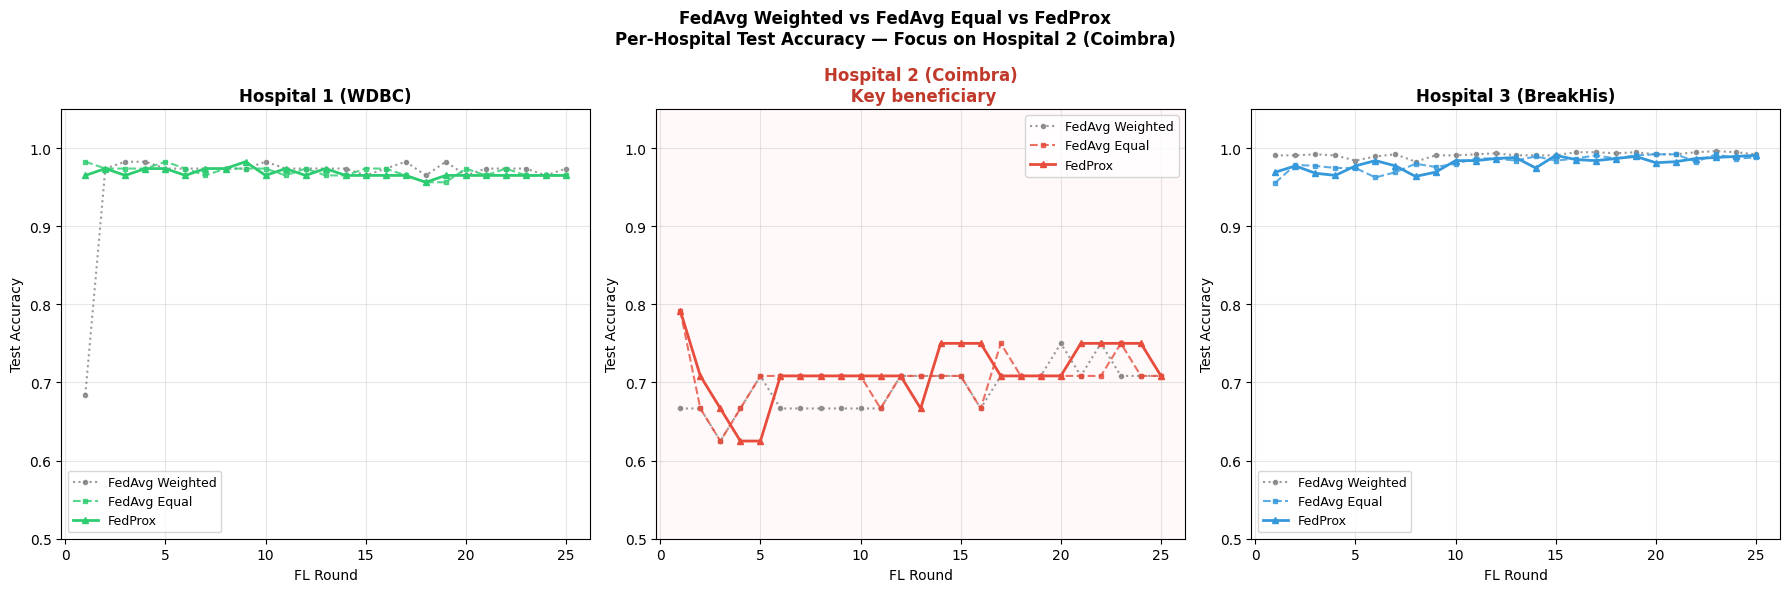


 Comparison plot saved


In [10]:
# COMPARE: Weighted FedAvg vs Equal FedAvg vs FedProx

# Loading previous histories
with open(
    os.path.join(BASE_PATH, 'results/federated/fl_history.json'),
    'r', encoding='utf-8'
) as f:
    fl_history_weighted = json.load(f)

with open(
    os.path.join(
        BASE_PATH,
        'results/federated/equal/fl_history_eq.json'
    ),
    'r', encoding='utf-8'
) as f:
    fl_history_equal = json.load(f)

# Best round indices
best_idx_w    = int(np.argmax(fl_history_weighted['avg_test_acc']))
best_idx_eq   = int(np.argmax(fl_history_equal['avg_test_acc']))
best_idx_prox = int(np.argmax(fl_history_prox['avg_test_acc']))

# Numerical comparison table
print(f"\n{'='*70}")
print(f"  THREE-WAY COMPARISON — BEST ROUND PER METHOD")
print(f"{'='*70}")
print(f"  Method          : FedAvg Weighted  FedAvg Equal   FedProx")
print(f"  Best round      : "
      f"{fl_history_weighted['round'][best_idx_w]:<16.0f}"
      f"{fl_history_equal['round'][best_idx_eq]:<16.0f}"
      f"{fl_history_prox['round'][best_idx_prox]:.0f}")
print(f"  {'─'*68}")

metrics_to_compare = [
    ('H1 Accuracy', 'h1_test_acc'),
    ('H1 F1-Score', 'h1_test_f1'),
    ('H1 AUC-ROC',  'h1_test_auc'),
    ('H2 Accuracy', 'h2_test_acc'),
    ('H2 F1-Score', 'h2_test_f1'),
    ('H2 AUC-ROC',  'h2_test_auc'),
    ('H3 Accuracy', 'h3_test_acc'),
    ('H3 F1-Score', 'h3_test_f1'),
    ('H3 AUC-ROC',  'h3_test_auc'),
]

for label, key in metrics_to_compare:
    w_val    = fl_history_weighted[key][best_idx_w]
    eq_val   = fl_history_equal[key][best_idx_eq]
    prox_val = fl_history_prox[key][best_idx_prox]
    best_val = max(w_val, eq_val, prox_val)

    def mark(v):
        return f"{v:.4f}{'*' if v == best_val else ' '}"

    print(f"  {label:<16}: "
          f"{mark(w_val):<16}"
          f"{mark(eq_val):<16}"
          f"{mark(prox_val)}")

print(f"  {'─'*68}")
print(f"  * = best for that metric")

# Hospital 2 focus — key finding
print(f"\n  KEY FINDING — Hospital 2 (Coimbra) across methods:")
print(f"  FedAvg Weighted best H2 Acc : "
      f"{max(fl_history_weighted['h2_test_acc']):.4f}")
print(f"  FedAvg Equal    best H2 Acc : "
      f"{max(fl_history_equal['h2_test_acc']):.4f}")
print(f"  FedProx         best H2 Acc : "
      f"{max(fl_history_prox['h2_test_acc']):.4f}")

# Plot — H2 accuracy across all three methods
# This is the thesis key plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'FedAvg Weighted vs FedAvg Equal vs FedProx\n'
    'Per-Hospital Test Accuracy — Focus on Hospital 2 (Coimbra)',
    fontsize=12, fontweight='bold'
)

hospital_data = [
    ('Hospital 1 (WDBC)',     'h1_test_acc', '#2ECC71'),
    ('Hospital 2 (Coimbra)',  'h2_test_acc', '#E74C3C'),
    ('Hospital 3 (BreakHis)', 'h3_test_acc', '#3498DB'),
]

for i, (name, key, color) in enumerate(hospital_data):
    ax = axes[i]

    ax.plot(
        fl_history_weighted['round'],
        fl_history_weighted[key],
        color='gray', linewidth=1.5,
        linestyle=':', marker='o', markersize=3,
        label='FedAvg Weighted', alpha=0.8
    )
    ax.plot(
        fl_history_equal['round'],
        fl_history_equal[key],
        color=color, linewidth=1.5,
        linestyle='--', marker='s', markersize=3,
        label='FedAvg Equal', alpha=0.8
    )
    ax.plot(
        [r for r in fl_history_prox['round']],
        fl_history_prox[key],
        color=color, linewidth=2,
        linestyle='-', marker='^', markersize=4,
        label='FedProx', alpha=1.0
    )

    ax.set_title(
        name + ('\n Key beneficiary' if i == 1 else ''),
        fontweight='bold',
        color='#C0392B' if i == 1 else 'black'
    )
    ax.set_xlabel('FL Round')
    ax.set_ylabel('Test Accuracy')
    ax.set_ylim([0.5, 1.05])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    if i == 1:
        ax.set_facecolor('#FFF9F9')

plt.tight_layout()
save_path = os.path.join(
    BASE_PATH,
    'results/federated/fedprox/three_method_comparison.png'
)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n Comparison plot saved")

### Summary

In [11]:
# STEP 2 SUMMARY
best_idx_prox = int(np.argmax(fl_history_prox['avg_test_acc']))

summary_prox = f"""
Algorithm     : FedProx + Equal Weighting
mu            : 0.01 (proximal strength)
FL rounds     : {num_fl_rounds_prox}
Local epochs  : {local_epochs_prox}
Weighting     : Equal (33.3% each)
Best round    : {fl_history_prox['round'][best_idx_prox]:.0f}

Results (best round):
              FedAvg Weighted   FedAvg Equal    FedProx
H1 Accuracy  {fl_history_weighted['h1_test_acc'][best_idx_w]:.4f}            {fl_history_equal['h1_test_acc'][best_idx_eq]:.4f}           {fl_history_prox['h1_test_acc'][best_idx_prox]:.4f}
H2 Accuracy  {fl_history_weighted['h2_test_acc'][best_idx_w]:.4f}            {fl_history_equal['h2_test_acc'][best_idx_eq]:.4f}           {fl_history_prox['h2_test_acc'][best_idx_prox]:.4f}
H3 Accuracy  {fl_history_weighted['h3_test_acc'][best_idx_w]:.4f}            {fl_history_equal['h3_test_acc'][best_idx_eq]:.4f}           {fl_history_prox['h3_test_acc'][best_idx_prox]:.4f}

H2 best across all methods:
  FedAvg Weighted : {max(fl_history_weighted['h2_test_acc']):.4f}
  FedAvg Equal    : {max(fl_history_equal['h2_test_acc']):.4f}
  FedProx         : {max(fl_history_prox['h2_test_acc']):.4f}

Saved files:
  results/federated/fedprox/fl_history_prox.json
  results/federated/fedprox/three_method_comparison.png
  models/federated/fedprox/best_global_shared_head_prox.pth
  models/federated/fedprox/best_h1_fedprox.pth
  models/federated/fedprox/best_h2_fedprox.pth
  models/federated/fedprox/best_h3_fedprox.pth

Next: Step 3 — FedProto
"""

print(summary_prox)

with open(
    os.path.join(
        BASE_PATH,
        'results/federated/fedprox/step2_summary.txt'
    ),
    'w', encoding='utf-8'
) as f:
    f.write(summary_prox)

print(" Summary saved: results/federated/fedprox/step2_summary.txt")


Algorithm     : FedProx + Equal Weighting
mu            : 0.01 (proximal strength)
FL rounds     : 25
Local epochs  : 2
Weighting     : Equal (33.3% each)
Best round    : 1

Results (best round):
              FedAvg Weighted   FedAvg Equal    FedProx
H1 Accuracy  0.9825            0.9825           0.9649
H2 Accuracy  0.7083            0.7917           0.7917
H3 Accuracy  0.9946            0.9556           0.9690

H2 best across all methods:
  FedAvg Weighted : 0.7500
  FedAvg Equal    : 0.7917
  FedProx         : 0.7917

Saved files:
  results/federated/fedprox/fl_history_prox.json
  results/federated/fedprox/three_method_comparison.png
  models/federated/fedprox/best_global_shared_head_prox.pth
  models/federated/fedprox/best_h1_fedprox.pth
  models/federated/fedprox/best_h2_fedprox.pth
  models/federated/fedprox/best_h3_fedprox.pth

Next: Step 3 — FedProto

 Summary saved: results/federated/fedprox/step2_summary.txt
